## Introduction
Google Trends data provides a way to track how public interest in a topic changes over time. In this post, I analyze search interest for the term “Armenian genocide” and compare it to public conversation on Twitter.

The main question is:
Do spikes in search interest align with spikes in public expression around Armenian Genocide Remembrance Day (April 24)?

## Data Sources

### Google Trends

I used Google Trends to collect weekly search interest data over the past five years for the  term:

“Armenian genocide”

Google Trends reports search interest on a 0–100 scale, where 100 represents the peak level of interest in the selected time period. This means the data reflects relative changes in attention rather than total search volume

## Twitter Data
To measure public expression, I used a dataset of tweets containing the hashtag `#1915neveragain`, which is commonly used in Armenian Genocide remembrance posts.

This dataset comes from a historical Twitter archive representing approximately 1% of total tweet volume, and can be aggregated over time to produce daily counts

## Google trends
Using the pytrends library

In [17]:
help(pytrends.build_payload)

Help on method build_payload in module pytrends.request:

build_payload(kw_list, cat=0, timeframe='today 5-y', geo='', gprop='') method of pytrends.request.TrendReq instance
    Create the payload for related queries, interest over time and interest by region



In [26]:
from pytrends.request import TrendReq


In [30]:
def get_gtrends_data_for_year(year, kw_list):
    pytrends = TrendReq()

    
    pytrends.build_payload(kw_list, timeframe=f'{year}-01-01 {year}-12-31')

    trends = pytrends.interest_over_time()

    return trends

In [31]:
kw_list = ["Armenian genocide"]

In [33]:
ag2012 = get_gtrends_data_for_year(2012, kw_list)

In [34]:
ag2013 = get_gtrends_data_for_year(2013, kw_list)

In [35]:
ag2014 = get_gtrends_data_for_year(2014, kw_list)

In [40]:
import time

In [44]:
gt_data = {}
for year in range(2022, 2027):
    print(f'Getting {year}')
    time.sleep(3)
    gt_data[year] = get_gtrends_data_for_year(year, kw_list)
    

Getting 2022
Getting 2023
Getting 2024
Getting 2025
Getting 2026


In [45]:
for year, gt_df in gt_data.items():
    gt_df.drop(columns='isPartial').to_csv(f'data/gtrends_armenian_genocide_{year}.csv')

<Axes: xlabel='date'>

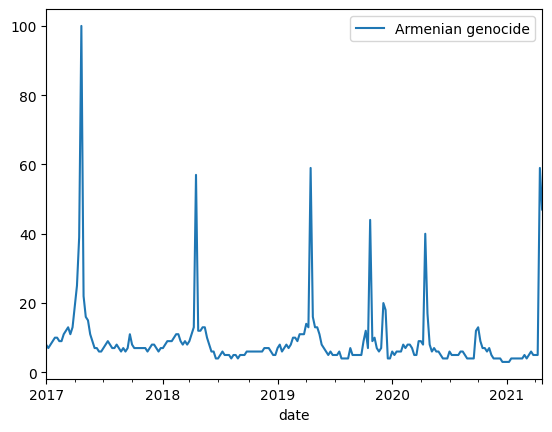

In [27]:
trends.plot()

In [28]:
trends

,Armenian genocide,isPartial
date,,
2017-01-01,8,False
2017-01-08,7,False
2017-01-15,8,False
2017-01-22,9,False
2017-01-29,10,False
...,...,...
2021-03-28,5,False
2021-04-04,5,False
2021-04-11,5,False
